In [29]:
import importlib
import utils
importlib.reload(utils)

import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

# Introduction
This notebook measures the time taken to
- generate the laplacian and time-step operator(s)
- generate the MPS of an input function
- generate the MPO of the time-step operator(s)
- evolve the input function by a specified number of `steps` via repeated multiplication with the time-step operator(s)
- evolve the MPS of the input function by a specified number of `steps` via repeated contractions with the time-step MPO(s)

for a list of specified values of `n`, where grid size `N = 2**n`.

# Parameters

In [30]:
ns = [6, 8, 10, 11, 12, 13, 14]  # values of n to iterate over, where grid size N = 2**n
steps = 200                      # number of steps required for time evolution
nu = 1e-3                        # diffusion coefficient 
cfl = 0.1                        # controls time step relative to grid spacing. affects stability of time-step scheme

def u(x):                        # our initial function
    return np.sin(2*np.pi*2*x) + 0.5*np.sin(2*np.pi*7*x)

# Experiment

In [ ]:
times_op     = []   # time taken to initialise laplacian and time-step operator(s)
times_mps    = []   # time taken to convert initial function u0 to MPS
times_mpo    = []   # time taken to convert time-step operator(s) to MPO(s)
times_ev_op  = []   # time taken to evolve the u0 via repeated multiplication of time-step operator(s)
times_ev_mps = []   # time taken to evolve the MPS representation of u0 via repeated contractions with MPO of time-step operator(s) 

for n in ns:
    N  = 2**n
    x  = np.linspace(0, 1, N, endpoint=False)
    dx = x[1] - x[0] 
    dt = utils.delta_t(cfl, dx, nu)
    u0 = u(x)
    
    t = time.perf_counter()
    L = utils.laplacian(N, dx, "periodic", "dense")
    A = utils.time_step(L, 2, dt, nu)
    t_op = time.perf_counter() - t

    t = time.perf_counter()
    mps0 = utils.vec_to_qtt_mps(u0, n)
    t_mps = time.perf_counter() - t

    t = time.perf_counter()
    mpoA = utils.mats_to_qtt_mpos(A, n)
    t_mpo = time.perf_counter() - t

    t = time.perf_counter()
    times, us, norms = utils.evolve_operator(u0, steps, A, dt)
    t_evolve_op = time.perf_counter() - t

    t = time.perf_counter()
    mps_saved, bond_track = utils.evolve_mps(mps0, mpoA, steps)
    t_evolve_mps = time.perf_counter() - t


    times_op.append(t_op)
    times_mps.append(t_mps)
    times_mpo.append(t_mpo)
    times_ev_op.append(t_evolve_op)
    times_ev_mps.append(t_evolve_mps)


 n  N = 2^n  setup (Op)  setup (TN)  evolution (Op)  evolution (TN)  speedup (evolution)
 6       64     0.02281     0.00283         0.02410         0.38952              0.06188
 8      256     0.00089     0.01161         0.00705         0.54855              0.01285
10     1024     0.01315     0.15605         0.10457         0.64729              0.16155
11     2048     0.09939     0.81912         0.46177         0.73012              0.63246
12     4096     0.29629     4.00673         1.70819         0.70478              2.42374
13     8192     2.02359    12.95902         5.38296         0.77301              6.96365
14    16384    10.48222    68.66709       325.35313         0.98905            328.95676


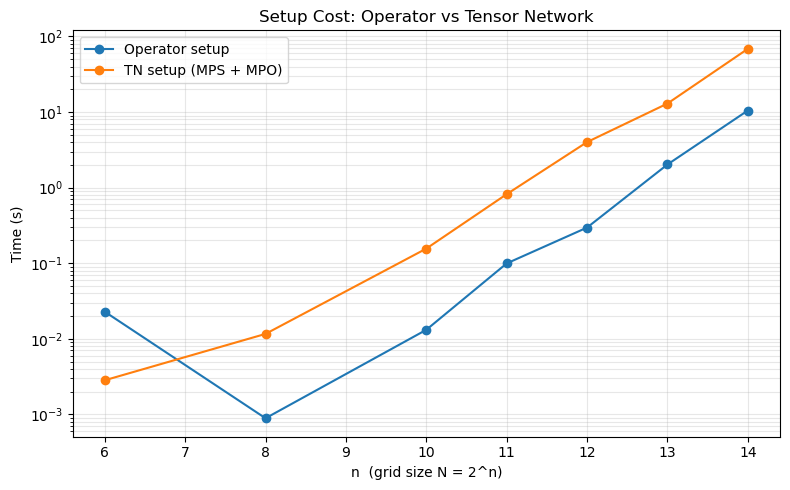

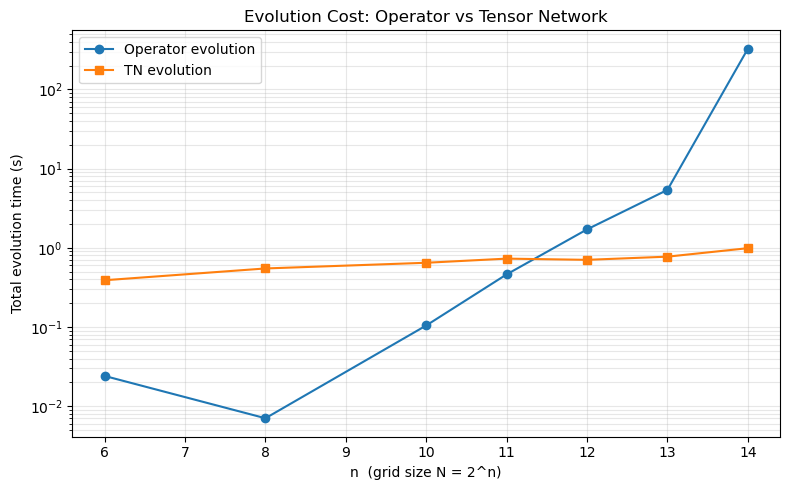

In [28]:
# ======================
# RAW NUMBERS COMPARISON
# ======================

N_vals = [2**n for n in ns]
df = pd.DataFrame({
    "n": ns,
    "N = 2^n": N_vals,
    "setup (Op)": times_op,
    "setup (TN)": [m + p for m, p in zip(times_mps, times_mpo)],
    "evolution (Op)": times_ev_op,
    "evolution (TN)": times_ev_mps,
})
df["speedup (evolution)"] = df["evolution (Op)"] / df["evolution (TN)"]
df = df.round(5)
print(df.to_string(index=False))



# ==============================
# INITIALISATION TIME COMPARISON
# ==============================

times_tn_setup = [m + p for m, p in zip(times_mps, times_mpo)]

plt.figure(figsize=(8,5))
plt.plot(ns, times_op, "o-", label="Operator setup")
plt.plot(ns, times_tn_setup, "o-", label="TN setup (MPS + MPO)")
plt.yscale("log")
plt.xlabel("n  (grid size N = 2^n)")
plt.ylabel("Time (s)")
plt.title("Setup Cost: Operator vs Tensor Network")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()



# =========================
# TIME EVOLUTION COMPARISON
# =========================

plt.figure(figsize=(8,5))

plt.plot(ns, times_ev_op, "o-", label="Operator evolution")
plt.plot(ns, times_ev_mps, "s-", label="TN evolution")

plt.yscale("log")
plt.xlabel("n  (grid size N = 2^n)")
plt.ylabel("Total evolution time (s)")
plt.title("Evolution Cost: Operator vs Tensor Network")

plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()